In [1]:
import sys
sys.path.insert(0, "..")

from rustic_ml.dataset import random_spec, render_mel
from rustic_ml.autoregressive import Vocabulary
from rustic_ml.autoregressive.tokenizer import spec_to_sequence
from rustic_py.rustic_py import render

import matplotlib.pyplot as plt
from IPython.display import Audio, display

ModuleNotFoundError: No module named 'rustic_ml.dataset'

In [2]:
def print_sequence(token_ids, cont_values, cat_values, vocab):
    """Pretty-print a token sequence with denormalised values."""
    open_toks  = {vocab.tokens[n] for n in ("<SOMS>", "<SOSD>", "<SOED>", "<SOFD>")}
    close_toks = {vocab.tokens[n] for n in ("<EOMS>", "<EOSD>", "<EOED>", "<EOFD>")}

    indent = 0
    pending_name   = None   # name of the last structural token (waiting for VALS)
    pending_indent = 0

    def _fmt_vals(tok_id, i):
        parts = []
        cont_fields = vocab.cont_layout.get(tok_id, [])
        if cont_fields:
            raw = vocab.denormalize_cont(tok_id, cont_values[i])
            parts += [f"{name}={raw[j]:.4g}" for j, name in enumerate(cont_fields)]
        cat_fields = vocab.cat_layout.get(tok_id, [])
        if cat_fields:
            parts += [f"{name}={int(cat_values[i][j])}" for j, name in enumerate(cat_fields)]
        return "  " + ",  ".join(parts) if parts else ""

    for i, tok_id in enumerate(token_ids):
        name = vocab.id_to_token[tok_id]

        if tok_id in close_toks:
            indent -= 1

        if tok_id == vocab.vals_tok:
            # Print pending structural token + its values on one line
            ctx = None
            if pending_name is not None:
                ctx = vocab.tokens[pending_name]
            vals_str = _fmt_vals(ctx, i) if ctx is not None else ""
            print("  " * pending_indent + f"{pending_name or '?':<20}{vals_str}")
            pending_name = None
        else:
            # Flush any pending structural token that had no VALS
            if pending_name is not None:
                print("  " * pending_indent + pending_name)
                pending_name = None

            if vocab.has_vals(tok_id):
                # Hold until we see VALS
                pending_name   = name
                pending_indent = indent
            else:
                print("  " * indent + name)

        if tok_id in open_toks:
            indent += 1


In [3]:
def generate_random_spec(complexity: float = 0.1):
    spec = random_spec(complexity)
    rendered = render(spec)
    mel = render_mel(spec)
    vocab = Vocabulary.from_rustic()
    token_ids, cont_values, cat_values = spec_to_sequence(spec, vocab)
    print(f"{len(token_ids)} tokens\n")
    print_sequence(token_ids, cont_values, cat_values, vocab)
    plt.figure()
    plt.imshow(mel, aspect="auto", origin="lower", cmap="magma")
    plt.colorbar()
    plt.tight_layout()
    plt.show()
    display(Audio(rendered.T if rendered.ndim == 2 else rendered, rate=44100))


# Vocabulary

## Values heads
Each `<VALS>` token carries values for two heads. The preceding structural token determines which head(s) are active and how many outputs each produces.

| Head | Type | Description |
|------|------|-------------|
| Continuous | bounded float [0,1] | Ranged params (filter params, frequency values, ADSR segments). ADSR duration fields use log-scale normalisation. |
| Categorical | integer class [0, N) | MIDI notes (128 classes), harmonic multipliers (32 classes), connection indices (32 classes). |

---

## Token table

### Control & special
Token | Name | Values
-|-|-
\<SOS\> | Start of Sequence | —
\<EOS\> | End of Sequence | —
\<VALS\> | Values | carries cont/cat values for the preceding structural token

### Graph-level
Token | Name | Values
-|-|-
NOTE | Note definition | cat: note (0–127) · cont: note_on, note_off (seconds)

### Multi-source block `<SOMS>...<EOMS>`
Token | Name | Values
-|-|-
\<SOMS\> | Start of Multi Source | —
\<EOMS\> | End of Multi Source | —
MM:sum | Mix Mode Sum | —
MM:avg | Mix Mode Average | —
MM:max | Mix Mode Max | —

### Source definition `<SOSD>...<EOSD>`
Token | Name | Values
-|-|-
\<SOSD\> | Start of Source Definition | —
\<EOSD\> | End of Source Definition | —
WF:sine | Waveform sine | —
WF:square | Waveform square | —
WF:sawtooth | Waveform sawtooth | —
WF:triangle | Waveform triangle | —
WF:whitenoise | Waveform white noise | —
WF:pinknoise | Waveform pink noise | —
WF:blank | Waveform blank | —
FR:identity | Freq. relation — identity | —
FR:harmonic | Freq. relation — harmonic | cat: harmonic_n (integer 1–32)
FR:offset | Freq. relation — Hz offset | cont: offset_hz (−2000 – +2000 Hz)
FR:ratio | Freq. relation — ratio | cont: ratio (0.1 – 10.0, log-scale)
FR:constant | Freq. relation — constant | cont: const_hz (20 – 8000 Hz, log-scale)
FR:semitones | Freq. relation — semitones | cont: semitones (−24 – +24)

### Envelope block `<SOED>...<EOED>`
Used for both per-source envelopes (inside `<SOSD>`) and the global amplitude envelope (directly inside `<SOMS>`).

Token | Name | Values
-|-|-
\<SOED\> | Start of Envelope | —
\<EOED\> | End of Envelope | —
ATK | Attack segment | cont: dur (log), peak, ctrl_time (log), ctrl_peak
DCY | Decay segment | cont: dur (log), peak, ctrl_time (log), ctrl_peak
SUS | Sustain level | cont: level [0, 1]
REL | Release segment | cont: dur (log), peak, ctrl_time (log), ctrl_peak

### Filter block `<SOFD>...<EOFD>`
Token | Name | Values
-|-|-
\<SOFD\> | Start of Filter | —
\<EOFD\> | End of Filter | —
FT:\<type_id\> | Filter type | cont: filter parameters (auto-generated from `available_filters()`)

### Connection tokens (after all source/filter blocks)
Token | Name | Values
-|-|-
CN:source_sink | Source → output | cat: src_idx (0–31)
CN:source_filter | Source → filter | cat: src_idx, flt_idx (0–31 each)
CN:filter_filter | Filter → filter | cat: flt_out_idx, flt_in_idx (0–31 each)
CN:filter_sink | Filter → output | cat: flt_idx (0–31)

---

## Full sequence example
```
<SOS>
NOTE  <VALS(cat:60; cont:0.0, 0.8)>
<SOMS>
  BF    <VALS(cont:440.0)>
  MM:avg
  <SOSD>
    WF:sine
    FR:identity
    <SOED>
      ATK <VALS(cont:0.01, 1.0, 0.01, 0.0)>
      DCY <VALS(cont:0.1,  0.8, 0.1,  1.0)>
      SUS <VALS(cont:0.8)>
      REL <VALS(cont:0.2,  0.0, 0.0,  0.0)>
    <EOED>
  <EOSD>
  <SOED>           ← glob_ampl envelope
    ATK <VALS(...)>  DCY <VALS(...)>  SUS <VALS(...)>  REL <VALS(...)>
  <EOED>
<EOMS>
<SOFD>
  FT:Lowpass  <VALS(cont:cutoff=0.5, resonance=0.3)>
<EOFD>
CN:source_filter  <VALS(cat:0, 0)>
CN:filter_sink    <VALS(cat:0)>
<EOS>
```


94 tokens

<SOS>
NOTE                  note_on=0.7428,  note_off=1.372,  note=42
<SOMS>
  MM:avg
  <SOSD>
    WF:saw
    FR:identity
    <SOED>
      ATK                   atk_dur=0.3546,  atk_peak=0.9397,  atk_ct=0.08834,  atk_cp=0.2106
      DCY                   dcy_dur=0.2799,  dcy_peak=0.8859,  dcy_ct=0.187,  dcy_cp=0.8961
      SUS                   sus_level=0.8859
      REL                   rel_dur=0.3984,  rel_peak=0,  rel_ct=0.2799,  rel_cp=0.1674
    <EOED>
  <EOSD>
  <SOSD>
    WF:sine
    FR:identity
    <SOED>
      ATK                   atk_dur=0.2102,  atk_peak=0.9745,  atk_ct=0.02029,  atk_cp=0.829
      DCY                   dcy_dur=0.2814,  dcy_peak=0.269,  dcy_ct=0.2047,  dcy_cp=0.4508
      SUS                   sus_level=0.269
      REL                   rel_dur=0.558,  rel_peak=0,  rel_ct=0.3197,  rel_cp=0.1799
    <EOED>
  <EOSD>
  <SOSD>
    WF:square
    FR:identity
    <SOED>
      ATK                   atk_dur=0.389,  atk_peak=0.9949,  atk_ct=0.1084,  atk_c

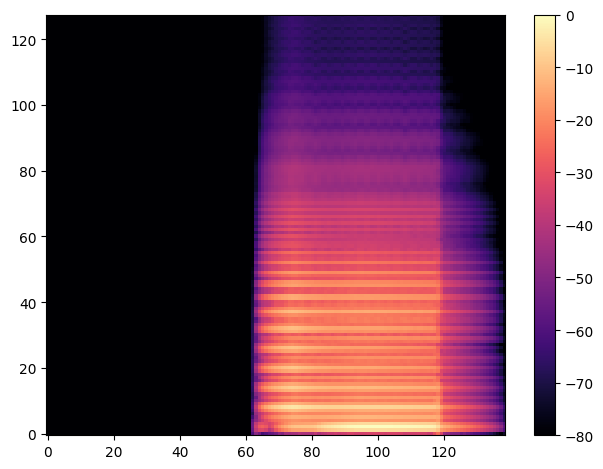

In [4]:
generate_random_spec(0.3)